In [3]:
import pandas as pd
import torch
from torch_geometric.data import Data
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

In [4]:
# Load the YouTube comment data
df = pd.read_csv('new_krish_youtube_comments.csv')

# Create user index mapping
user_ids = df['author_channel_id'].unique()
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}

# Map sentiment to numerical values
sentiment_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}
df['sentiment'] = df['sentiment'].map(sentiment_mapping)


# Build edge list and edge attributes
edges = []
edge_attrs = []

# Track interactions for timestamps
first_interaction = {}
last_interaction = {}

for _, row in df.iterrows():
    if not pd.isna(row['parent_id']):
        # Find parent comment
        parent = df[df['comment_id'] == row['parent_id']]
        if not parent.empty:
            source = user_to_idx[row['author_channel_id']]
            target = user_to_idx[parent['author_channel_id'].values[0]]

            # Avoid self-loops
            if source != target:
                edges.append((source, target))

                # Track first and last interaction timestamps
                key = (source, target)
                timestamp = pd.to_datetime(row['published_at'])
                if key not in first_interaction:
                    first_interaction[key] = timestamp
                    last_interaction[key] = timestamp
                else:
                    if timestamp < first_interaction[key]:
                        first_interaction[key] = timestamp
                    if timestamp > last_interaction[key]:
                        last_interaction[key] = timestamp


# Create edge index tensor
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Create edge attributes (weight, time_diff)
edge_attr = []
for edge in edges:
    time_diff = (last_interaction[edge] - first_interaction[edge]).days
    edge_attr.append([1, time_diff])  # [weight, time_diff]
edge_attr = torch.tensor(edge_attr, dtype=torch.float)


# Node features: [avg_sentiment, avg_likes, reply_count]
node_features = []
for user_id in user_ids:
    user_comments = df[df['author_channel_id'] == user_id]
    avg_sentiment = user_comments['sentiment'].mean()
    avg_likes = user_comments['like_count'].mean()
    reply_count = len(user_comments[user_comments['parent_id'].notna()])
    node_features.append([avg_sentiment, avg_likes, reply_count])

x = torch.tensor(node_features, dtype=torch.float)

# Create PyG data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [5]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import degree

class InfluencePropagator(torch.nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim=64):
        super().__init__()
        self.conv1 = GATConv(node_dim, hidden_dim, edge_dim=edge_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim, edge_dim=edge_dim)
        self.prob_predictor = torch.nn.Linear(hidden_dim, 1)
        
    def forward(self, x, edge_index, edge_attr):
        # Message passing
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        
        # Activation probability
        return torch.sigmoid(self.prob_predictor(x))

def simulate_influence(model, data, seed_nodes, steps=5):
    """Simulate influence propagation through the network"""
    activation = torch.zeros(data.num_nodes)
    activation[seed_nodes] = 1.0  # Seed initial activation
    
    activation_history = [activation.clone().numpy()]
    
    for step in range(steps):
        # Predict activation probabilities
        with torch.no_grad():
            probs = model(data.x, data.edge_index, data.edge_attr).squeeze()
        
        # Determine new activations
        new_activation = torch.zeros(data.num_nodes)
        active_indices = torch.where(activation == 1)[0]
        
        for node in active_indices:
            # Get neighbors
            neighbors = data.edge_index[1][data.edge_index[0] == node]
            
            # Activate neighbors based on probability
            for neighbor in neighbors:
                if activation[neighbor] == 0 and torch.rand(1) < probs[neighbor]:
                    new_activation[neighbor] = 1
        
        # Update activation states
        activation = torch.clamp(activation + new_activation, 0, 1)
        activation_history.append(activation.numpy())
    
    return activation_history

In [6]:
# Create NetworkX graph for centrality calculation
G = nx.DiGraph()
for i in range(data.edge_index.shape[1]):
    src = data.edge_index[0, i].item()
    dst = data.edge_index[1, i].item()
    G.add_edge(src, dst)

# Calculate centrality metrics
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Find top central nodes
top_degree = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]
top_betweenness = sorted(betweenness_centrality, key=betweenness_centrality.get, reverse=True)[:5]

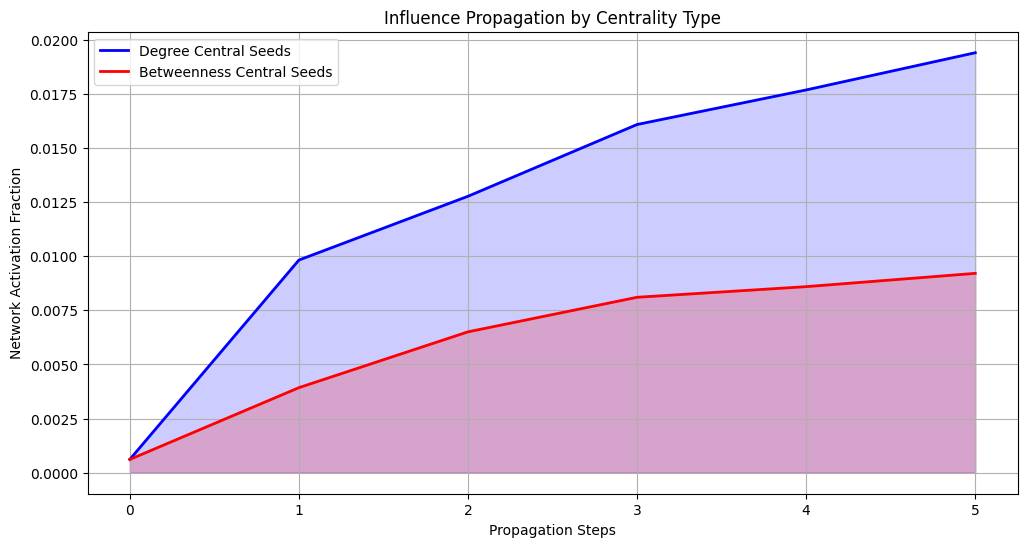

In [7]:
# Initialize model
model = InfluencePropagator(node_dim=3, edge_dim=2)

# Simulate propagation for different centrality types
degree_spread = simulate_influence(model, data, top_degree)
betweenness_spread = simulate_influence(model, data, top_betweenness)

# Visualize propagation
plt.figure(figsize=(12, 6))
plt.plot([s.mean() for s in degree_spread], 'b-', label='Degree Central Seeds', linewidth=2)
plt.plot([s.mean() for s in betweenness_spread], 'r-', label='Betweenness Central Seeds', linewidth=2)
plt.fill_between(range(len(degree_spread)), 
                 [s.mean() for s in degree_spread], alpha=0.2, color='blue')
plt.fill_between(range(len(betweenness_spread)), 
                 [s.mean() for s in betweenness_spread], alpha=0.2, color='red')
plt.title('Influence Propagation by Centrality Type')
plt.xlabel('Propagation Steps')
plt.ylabel('Network Activation Fraction')
plt.legend()
plt.grid(True)
plt.savefig('centrality_influence.png', dpi=300)
plt.show()

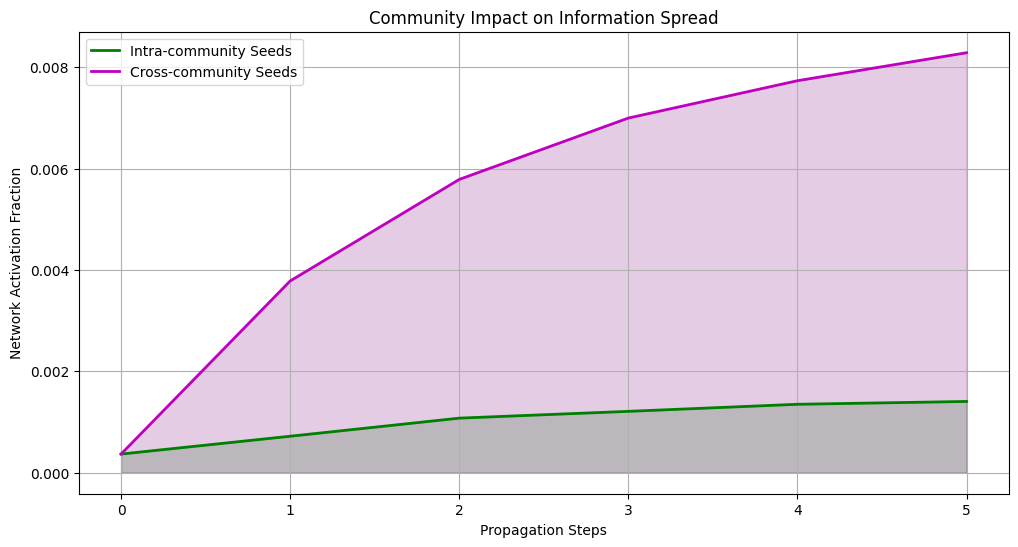

In [8]:
import numpy as np

# Detect communities
from community import community_louvain
partition = community_louvain.best_partition(G.to_undirected())

# Simulate intra-community vs cross-community spread
intra_spread = []
cross_spread = []

for comm_id in set(partition.values()):
    # Get community members
    community_nodes = [n for n in G.nodes if partition[n] == comm_id]
    
    if len(community_nodes) > 10:
        # Intra-community seeds
        intra_seeds = [community_nodes[i] for i in [0, 2, 4]]  # Select 3 nodes
        intra_spread.append(simulate_influence(model, data, intra_seeds))
        
        # Cross-community seeds
        cross_seeds = [n for n in G.nodes if partition[n] != comm_id][:3]
        cross_spread.append(simulate_influence(model, data, cross_seeds))

# Visualize results
intra_avg = np.array(intra_spread).mean(axis=0)
cross_avg = np.array(cross_spread).mean(axis=0)

plt.figure(figsize=(12, 6))
plt.plot(intra_avg.mean(axis=1), 'g-', label='Intra-community Seeds', linewidth=2)
plt.plot(cross_avg.mean(axis=1), 'm-', label='Cross-community Seeds', linewidth=2)
plt.fill_between(range(len(intra_avg)), intra_avg.mean(axis=1), alpha=0.2, color='green')
plt.fill_between(range(len(cross_avg)), cross_avg.mean(axis=1), alpha=0.2, color='purple')
plt.title('Community Impact on Information Spread')
plt.xlabel('Propagation Steps')
plt.ylabel('Network Activation Fraction')
plt.legend()
plt.grid(True)
plt.savefig('community_impact.png', dpi=300)
plt.show()

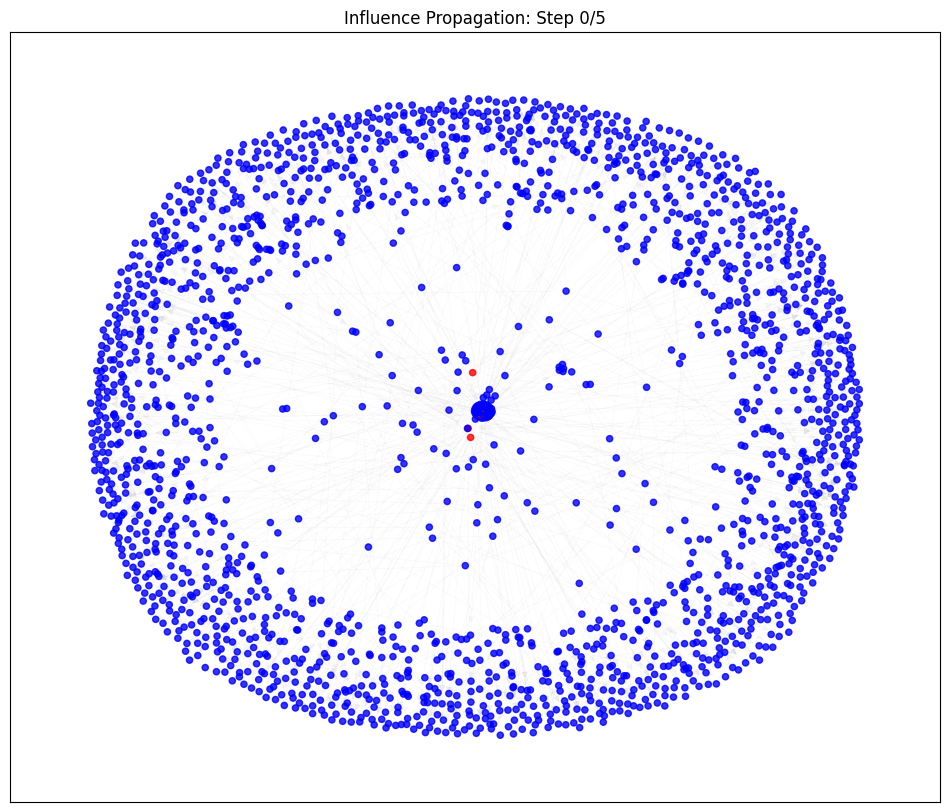

In [9]:
# Create animated propagation visualization
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap

# Create position layout
pos = nx.spring_layout(G, seed=42)

# Run simulation
activation_history = simulate_influence(model, data, top_degree)

# Create colormap: blue (inactive) to red (active)
cmap = LinearSegmentedColormap.from_list("propagation", ["blue", "red"])

fig, ax = plt.subplots(figsize=(12, 10))

def update(frame):
    ax.clear()
    # Filter activation history to only include nodes present in pos
    nodes_to_draw = list(pos.keys())
    node_colors = [activation_history[frame][node] for node in nodes_to_draw]

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodes_to_draw,
        node_size=20,
        node_color=node_colors,
        cmap=cmap,
        vmin=0,
        vmax=1,
        alpha=0.8
    )
    nx.draw_networkx_edges(
        G, pos,
        edge_color='gray',
        alpha=0.05,
        width=0.5
    )
    ax.set_title(f'Influence Propagation: Step {frame}/{len(activation_history)-1}')
    return ax

ani = FuncAnimation(fig, update, frames=len(activation_history), interval=800)
ani.save('influence_propagation.gif', writer='pillow', dpi=150)